The kinematics of a two-wheel robot can be given by: 
\begin{equation}
\begin{aligned}
\dot{x} &= v \sin(\theta) \\
\dot{y} &= v \cos(\theta) \\
v &= \frac{r}{2}(\omega_1 + \omega_2) \\
\dot{\theta} &= \frac{r}{L}(\omega_1 + \omega_2) \\
\end{aligned}
\end{equation}

$(x,y)$ are coordinates of the center of the wheelbase, $\theta$ is the angle of the line perpendicular to the line joining the wheels, relative to the straight line. $\omega_1, \omega_2$ are angular rates of the left and right wheels respectively. 


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [11]:
# system constants
r = 0.025
L = 0.15
v = 0.1
T = 30
line_x = 0.0

In [12]:
def kinematic_model(t, state, omega1, omega2, r, L):
    "first order differential equations for the kinematics"
    "of a two wheel drive robot"
    x, y, theta = state
    v = r * (omega1 + omega2) / 2
    theta_dot = r * (omega1 - omega2) / L
    dx = v * np.sin(theta)
    dy = v * np.cos(theta)
    return np.array([dx, dy, theta_dot])

Open loop simulation

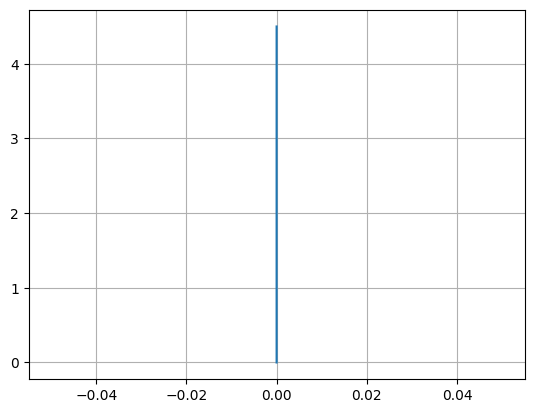

In [13]:
state0 = [0.0, 0.0, 0.0]
t_span = (0,T)
dt = 0.001
t_eval = np.arange(t_span[0], t_span[1], dt)

omega1 = 6.0
omega2 = 6.0

sol = solve_ivp(
    kinematic_model, 
    t_span, 
    state0, 
    t_eval = t_eval, 
    args = (omega1, omega2, r, L), 
    method = 'RK45'
)

x = sol.y[0]
y = sol.y[1]
theta = sol.y[2]
plt.plot(x, y)
plt.grid(True)
plt.show()

Sensor Locations: 
\begin{equation}
    (s_i, d)
\end{equation}


In [14]:
thickness = 0.02 # 2cm
sensor_offsets = [-0.02, -0.005, 0.005, 0.02]
d = 0.20
def sensor_readings(x, y, theta, sensor_offsets, d = d, line_x = 0, t_line = thickness):
    """
    x, y, theta: robot state
    sensor_offsets: array of lateral offsets s_i
    d: forward offset along y_body
    line_x : x coordinate of the line
    thickness : line thickness
    """
    readings = []
    for s in sensor_offsets:
        # sensor locations in world frame
        x_i = x + d * np.sin(theta) + s * np.cos(theta) 
        y_i = y + d * np.cos(theta) + s * np.sin(theta)
        
        # whether the sensors are on the line or not
        readings.append(1 if abs(x_i - line_x) <= thickness/2 else 0)
    return np.array(readings)

We now consider the discrete error function of the form: 
\begin{equation}
e = \frac{\sum x_i S_i}{\sum S_i}
\end{equation}
where $S_i$ are whether each of the sensors are on the line or not. So 1 if on the line, 0 if off the line. 
Then the control law would be: 
\begin{equation}
\dot{\theta}_d = K_p e + K_d \dot{e} + K_i \int_{0}^{t} e(\tau) d\tau
\end{equation}

Converting to wheel speeds: 
\begin{equation}
\omega_1 = \frac{v_c + \frac{L}{2} \dot{\theta}_d}{r} \qquad \omega_2 = \frac{v_c + \frac{L}{2} \dot{\theta}_d}{r}
\end{equation}

In [15]:
def weighted_sum(readings, sensor_offsets, prev_error=0.0):
    active = sum(readings)
    if active == 0:
        return prev_error  # fallback if no sensors detect line
    error = sum(s * r_i for s, r_i in zip(readings, sensor_offsets))
    return error / active

In [16]:
Kp, Ki, Kd = 5.0, 0.0, 0.02
dt_pid = 0.01  # PID sampling time (s)

class PIDController:
    def __init__(self, Kp, Ki, Kd, dt):
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.dt = dt
        self.prev_error = 0.0
        self.I = 0.0
        self.u = 0.0  # last control output

    def update(self, error):
        P = self.Kp * error
        self.I += self.Ki * error * self.dt
        D = self.Kd * (error - self.prev_error) / self.dt
        self.u = P + self.I + D
        self.prev_error = error
        return self.u

pid = PIDController(Kp, Ki, Kd, dt_pid)

In [17]:
omega1 = v/r
omega2 = v/r
last_pid_time = 0.0
predicted_error = 0.0
# new kinematic model with control law
def robot_kinematics(t, state):
    global omega1, omega2, last_pid_time, predicted_error
    x, y, theta = state

    # Update PID if enough time has passed
    if t - last_pid_time >= dt_pid:
        readings = sensor_readings(x, y, theta, sensor_offsets, d, line_x, thickness)
        if sum(readings) > 0:
            # Sensor sees line → use measured error
            e = weighted_sum(readings, sensor_offsets, predicted_error)
            predicted_error = e
        else:
            # No sensors active → predict error using angular rate
            theta_dot = r * (omega1 - omega2) / L
            predicted_error += v * np.sin(theta) * dt_pid  # linear approximation

        u = pid.update(predicted_error)
        omega1 = (v + (L/2)*u)/r
        omega2 = (v - (L/2)*u)/r
        last_pid_time = t

    # Robot kinematics
    v_forward = r * (omega1 + omega2)/2
    theta_dot = r * (omega1 - omega2)/L
    dx = v_forward * np.sin(theta)
    dy = v_forward * np.cos(theta)
    dtheta = theta_dot
    return [dx, dy, dtheta]

t_span = (0,T)
t_eval = np.arange(t_span[0], t_span[1], dt)

#initial conditions
X0 = [-0.02, 0.0, 0.0 ] # initial error in x direction and heading 

sol = solve_ivp(robot_kinematics, t_span, X0, t_eval=t_eval, method='RK45')

0.02
[0 0 0 1]


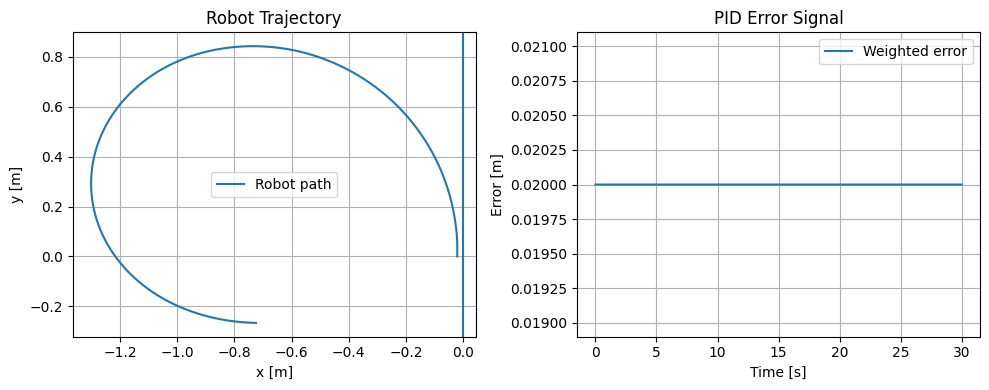

In [18]:
error_history = []
readings_history = []
prev_e = 0.0
for x, y, theta in zip(sol.y[0], sol.y[1], sol.y[2]):
    readings = sensor_readings(x, y, theta, sensor_offsets, d, line_x, thickness)
    e = weighted_sum(readings, sensor_offsets, prev_e)
    readings_history.append(readings)
    error_history.append(e)
    prev_e = e

print(error_history[0])
print(readings_history[0])

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(sol.y[0], sol.y[1], label='Robot path')
plt.axvline(x = 0, ymin  = 0.0, ymax = 2.0)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Robot Trajectory')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(sol.t, error_history, label='Weighted error')
plt.xlabel('Time [s]')
plt.ylabel('Error [m]')
plt.title('PID Error Signal')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()